In [1]:
#Osnovne biblioteke

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter
from collections import Counter
from scipy.stats import randint
from pathlib import Path


In [2]:
#Scikit-learn – pipeline i transformacije

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    QuantileTransformer,
    FunctionTransformer,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
#Scikit-learn – modeli

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.neural_network import MLPRegressor

In [4]:
#Scikit-learn – evaluacija, metrika i 

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error,
    make_scorer
)
from sklearn.inspection import permutation_importance

In [5]:
import warnings
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [6]:
# #Boosting modeli

# import xgboost as xgb
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor

In [7]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\Sberbank\Sberbank-House-Pricing


In [8]:
data = pd.read_csv(current_directory+"/train.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [9]:
df.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

In [10]:
print(df.dtypes.unique())

[dtype('int64') dtype('O') dtype('float64')]


In [11]:
df.drop(columns=['id'], inplace=True)

In [12]:
df.shape

(30471, 291)

In [13]:
# prag za periferiju (npr. stanovi dalje od 30 km od Kremlja)
df = df[df["kremlin_km"] <= 30].copy()

In [14]:
target = df["price_doc"]
print(target.isna().sum())

0


In [15]:
print(df["price_doc"].head())
print(df["price_doc"].min(), df["price_doc"].max())

0     5850000
1     6000000
2     5700000
3    13100000
4    16331452
Name: price_doc, dtype: int64
100000 111111112


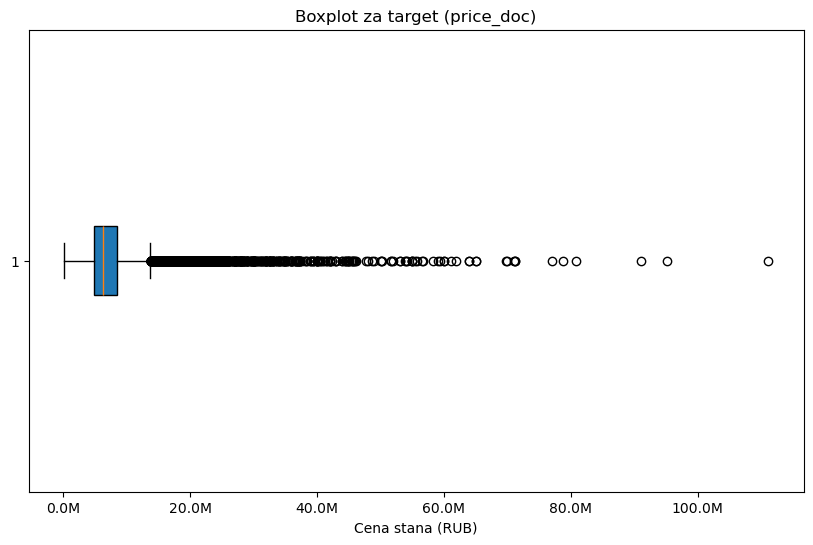

In [16]:

plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

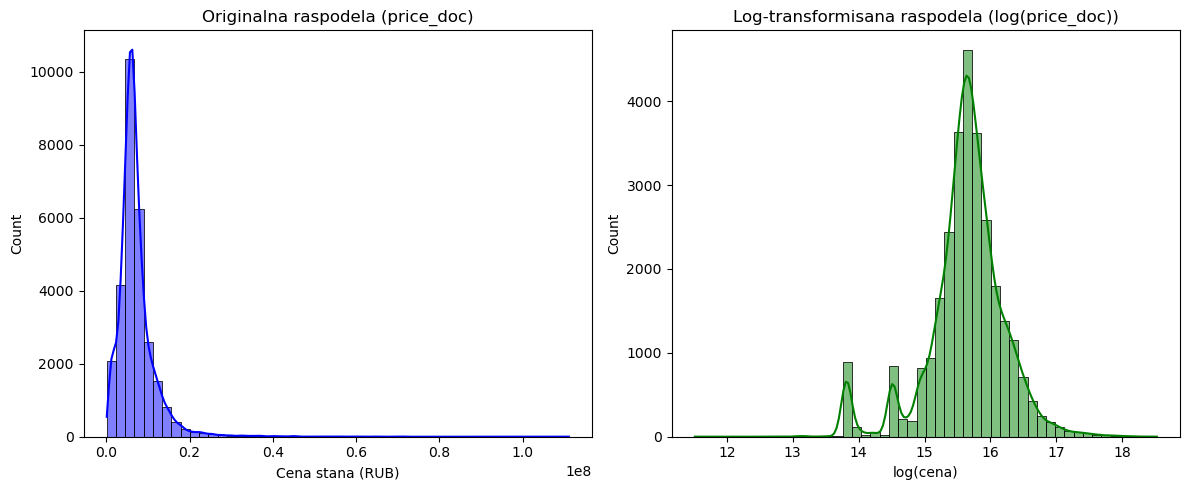

In [17]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["price_doc"], kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(df["price_doc"]), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [18]:
new_cols = []

In [19]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
start = df["timestamp"].min()

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month

df.drop(columns=['timestamp'], inplace=True)
new_cols.extend(["year","month"])

In [20]:
df.shape

(28906, 292)

In [21]:
df["floor_ratio"] = df.apply(
    lambda row: row["floor"] / row["max_floor"] if pd.notnull(row["max_floor"]) and row["max_floor"] > 0 else 0,
    axis=1
)

In [22]:
df["build_age"] = df["year"] - df["build_year"]
new_cols.extend(["floor_ratio","build_age"])

In [23]:
df.shape

(28906, 294)

In [24]:
cols = [c for c in df.columns if c != 'price_doc'] + ['price_doc']
df = df[cols]

In [25]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [26]:
print(y.name)

price_doc


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
y_train.head()

6941     5796000
12866    6095313
604      5800000
12523    3000000
6467     6517253
Name: price_doc, dtype: int64

In [29]:
"""Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_train = X_train.loc[mask]
y_train = y_train.loc[mask]"""

lower = y_train.quantile(0.01)
upper = y_train.quantile(0.85)

mask = (y_train >= lower) & (y_train <= upper)

X_train_clean = X_train.loc[mask]
y_train_clean = y_train.loc[mask]

In [30]:
df = df.dropna(subset=["price_doc"]).copy()

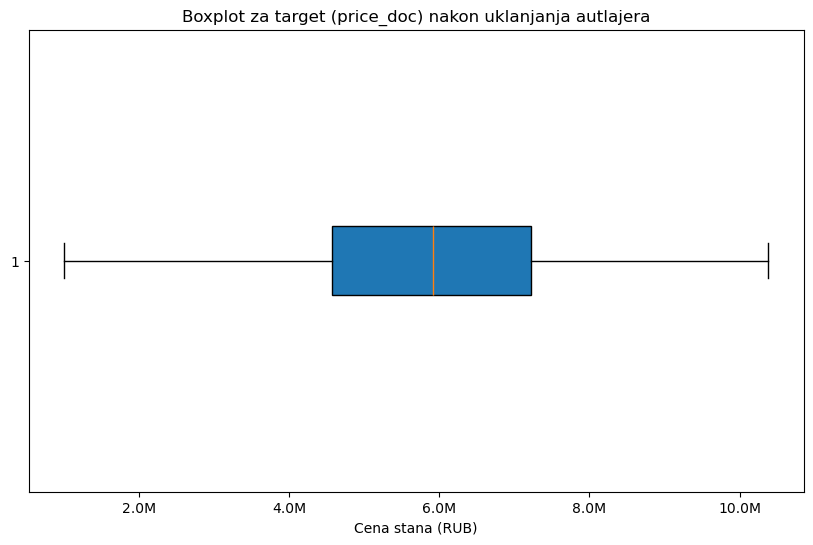

In [31]:
plt.figure(figsize=(10,6))
plt.boxplot(y_train_clean, vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc) nakon uklanjanja autlajera")
plt.xlabel("Cena stana (RUB)")
plt.show()

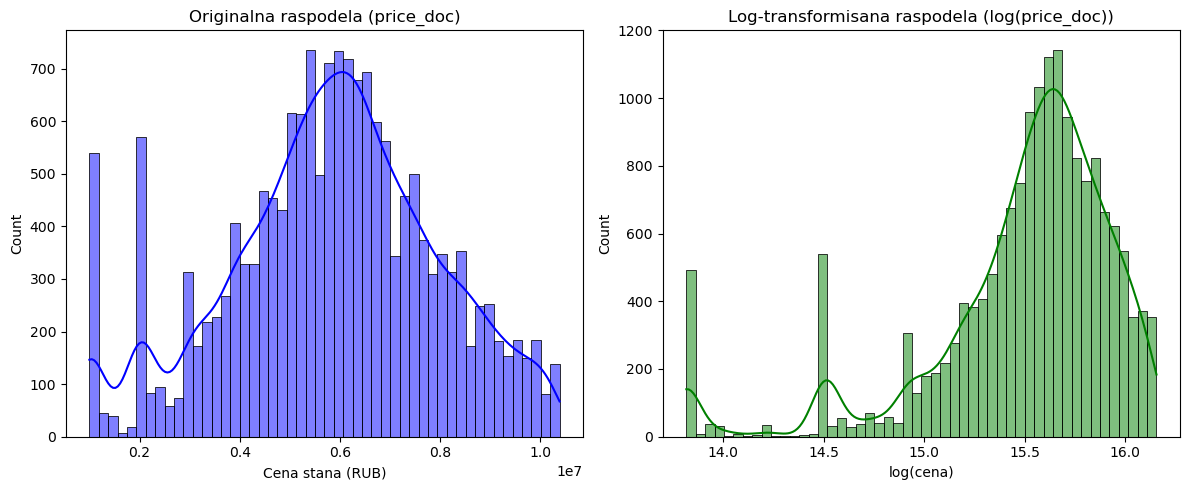

In [32]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_train_clean, kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(y_train_clean), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [33]:
df["price_doc_log"] = np.log1p(df["price_doc"])

In [34]:
df["price_per_m2"] = df["price_doc"] / df["full_sq"]
df = df[df["price_per_m2"].notnull() & (df["price_per_m2"] < 1_000_000)].copy() 

# Log transformacija
df["log_price_per_m2"] = np.log(df["price_per_m2"])

In [35]:
y_train_clean = np.log1p(y_train_clean)

### Test

In [37]:
def missing_values_ratio(df, ratio_for_na_values=0.3, target_col="price_doc", corr_threshold=0.4):
    # 1. Missing ratio for each column
    missing_ratio = df.isnull().mean().sort_values(ascending=False)
    
    # 2. Select only columns with > threshold % missing
    cols_over_n = missing_ratio[missing_ratio > ratio_for_na_values]
    cols_to_drop = []
    
    if not cols_over_n.empty:
        print(f"Kolone sa preko {round(ratio_for_na_values*100)}% nedostajućih vrednosti:\n")
        
        # 3. For each such column, compute correlation with target
        for col in cols_over_n.index:
            if df[col].dtype in ['int64', 'float64']:  # only numeric can correlate
                corr_val = df[[col, target_col]].corr().iloc[0, 1]  # correlation col <-> target
                if (corr_val is None) or (abs(corr_val) < corr_threshold):
                    cols_to_drop.append(col)
                print(f"{col}: {cols_over_n[col]*100:.2f}% NaN, korelacija sa targetom = {corr_val:.3f}")
        return cols_to_drop
    else:
        print("Nema takvih kolona")
        return []

In [38]:
columns_to_drop = missing_values_ratio(df, 0.3, "price_doc", 0.4)

Kolone sa preko 30% nedostajućih vrednosti:

hospital_beds_raion: 46.70% NaN, korelacija sa targetom = 0.140
build_age: 44.78% NaN, korelacija sa targetom = -0.002
build_year: 44.78% NaN, korelacija sa targetom = 0.002
state: 44.56% NaN, korelacija sa targetom = 0.120
cafe_avg_price_500: 41.63% NaN, korelacija sa targetom = 0.034
cafe_sum_500_min_price_avg: 41.63% NaN, korelacija sa targetom = 0.033
cafe_sum_500_max_price_avg: 41.63% NaN, korelacija sa targetom = 0.034
max_floor: 31.95% NaN, korelacija sa targetom = 0.084
material: 31.95% NaN, korelacija sa targetom = 0.067
num_room: 31.95% NaN, korelacija sa targetom = 0.485
kitch_sq: 31.95% NaN, korelacija sa targetom = 0.037


In [39]:
print(len(X_test.columns.tolist()))

293


In [40]:
df = df.drop(columns = columns_to_drop)

In [41]:
X_test = X_test.drop(columns=columns_to_drop)  
X_train = X_train_clean.drop(columns=columns_to_drop) 

In [42]:
X_train.shape, X_test.shape

((17045, 283), (8672, 283))

In [43]:
train_imputer = SimpleImputer

In [44]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [45]:
train_num = X_train[num_cols].copy()
train_cat = X_train[cat_cols].copy()

In [46]:
train_num.shape, train_cat.shape

((17045, 266), (17045, 15))

In [47]:
for cat in cat_cols:
    print(cat)
    print(train_cat[cat].unique())

product_type
['OwnerOccupier' 'Investment']
sub_area
['Poselenie Sosenskoe' "Tekstil'shhiki" 'Levoberezhnoe' 'Strogino'
 'Pokrovskoe Streshnevo' 'Beskudnikovskoe' 'Tverskoe' 'Jasenevo'
 "Gol'janovo" 'Marfino' 'Danilovskoe' 'Juzhnoe Medvedkovo' 'Mitino'
 'Ljublino' 'Cheremushki' 'Vojkovskoe' 'Kuncevo' 'Birjulevo Zapadnoe'
 'Lianozovo' "Mar'ino" 'Juzhnoe Butovo' 'Babushkinskoe'
 'Severnoe Izmajlovo' "Moskvorech'e-Saburovo" 'Sokol' 'Dmitrovskoe'
 'Novogireevo' 'Poselenie Moskovskij' 'Lefortovo' 'Perovo'
 "Chertanovo Central'noe" 'Veshnjaki' 'Ajeroport' 'Nekrasovka' 'Zjuzino'
 'Poselenie Vnukovskoe' 'Poselenie Voskresenskoe' 'Mozhajskoe'
 'Nagatino-Sadovniki' 'Zapadnoe Degunino' 'Poselenie Desjonovskoe'
 'Filevskij Park' 'Nagornoe' "Mar'ina Roshha" 'Bogorodskoe' "Kuz'minki"
 'Ochakovo-Matveevskoe' 'Ostankinskoe' 'Kosino-Uhtomskoe'
 'Severnoe Tushino' 'Jaroslavskoe' 'Poselenie Filimonkovskoe' 'Solncevo'
 'Otradnoe' 'Severnoe Medvedkovo' 'Novokosino' 'Vostochnoe Izmajlovo'
 'Poselenie Shherb

In [48]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols + freq_cols]

In [49]:
print(nominal_cols)

['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']


In [50]:
train_cat["ecology"] = train_cat["ecology"].replace("no data", np.nan)
train_cat = train_cat.replace(["nan", "NaN", ""], np.nan)
imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
train_cat = imputer.fit_transform(train_cat)

In [51]:
train_cat.isna().sum().sum()

0

In [52]:
imputer_num = SimpleImputer(strategy="median").set_output(transform="pandas")
train_num = imputer.fit_transform(train_num)

train_num.isna().sum().sum()

0

In [53]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X

In [54]:
def categorical_to_numeric(df_obj, nominal_cols, ordinal_cols, freq_cols):
    if freq_cols:
        fe = FrequencyEncoder(columns=freq_cols, normalize=True)
        df_obj[freq_cols] = fe.fit_transform(df_obj[freq_cols])


    if nominal_cols:
        ohe = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
        df_encoded = pd.DataFrame(
            ohe.fit_transform(df_obj[nominal_cols]),
            columns=ohe.get_feature_names_out(nominal_cols),
            index=df_obj.index
        )
        df_obj = df_obj.drop(columns=nominal_cols)
        df_obj = pd.concat([df_obj, df_encoded], axis=1)

    if ordinal_cols:
        order = [["excellent", "good", "satisfactory", "poor"]]
        enc = OrdinalEncoder(categories=order)
        for col in ordinal_cols:
            df_obj[col] = enc.fit_transform(df_obj[[col]])

    return df_obj

In [55]:
train_cat_to_num = categorical_to_numeric(train_cat, nominal_cols, ordinal_cols, freq_cols)

In [56]:
train_cat_to_num.shape

(17045, 15)

In [57]:
train_cat_with_target = train_cat_to_num.copy()
train_cat_with_target['price_doc'] = y_train 

corr = train_cat_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.25) | (corr <= -0.25)])

price_doc    1.0
Name: price_doc, dtype: float64


In [58]:
def columns_selector(train_num_with_target, corr_treshold = 0.25):
    
    corr_matrix = train_num_with_target.corr(numeric_only=True)
    target_corr = corr_matrix["price_doc"].drop("price_doc")
    selected_features = target_corr[target_corr.abs() > corr_treshold].index.tolist()
    
    print(f"Feature-i sa korelacijom > {corr_treshold} sa targetom:")
    print(selected_features)

    return selected_features

Feature-i sa korelacijom > 0.1 sa targetom:
['sub_area', 'product_type_OwnerOccupier']


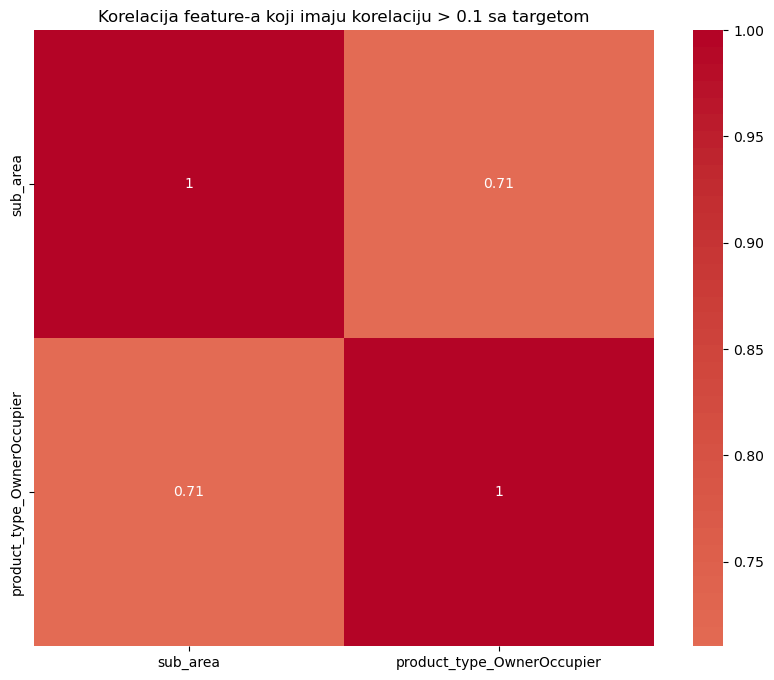

In [59]:
corr_treshold = 0.1
selected_features = columns_selector(train_cat_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_cat_with_target[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [60]:
train_cat_to_num.head()

,sub_area,ecology,product_type_OwnerOccupier,culture_objects_top_25_yes,thermal_power_plant_raion_yes,incineration_raion_yes,oil_chemistry_raion_yes,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes
6941,0.072103,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
12866,0.011440,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
604,0.003813,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12523,0.008331,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6467,0.005280,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
def winsorize_all_numeric(df, lower=0.01, upper=0.99):
    df_copy = df.copy()
    num_cols = df_copy.select_dtypes(include=["number"])

    # odredi granice po kolonama
    q_low = num_cols.quantile(lower)
    q_high = num_cols.quantile(upper)

    # vektorski clip: za svaku kolonu koristi njen min/max prag
    df_copy[num_cols.columns] = num_cols.clip(lower=q_low, upper=q_high, axis=1)
    return df_copy

In [62]:
df = winsorize_all_numeric(df, lower=0.01, upper=0.99)

In [63]:
df.shape

(28878, 287)

In [64]:
train_num_with_target = train_num.copy()
train_num_with_target['price_doc'] = y_train 

corr = train_num_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.2) | (corr <= -0.2)])

price_doc               1.000000
num_room                0.301740
workplaces_km          -0.202930
basketball_km          -0.202967
fitness_km             -0.203139
ts_km                  -0.206087
preschool_km           -0.208685
school_km              -0.208712
swim_pool_km           -0.215080
big_church_km          -0.229545
metro_min_avto         -0.240322
public_healthcare_km   -0.241880
metro_km_avto          -0.245797
metro_km_walk          -0.248467
metro_min_walk         -0.248467
Name: price_doc, dtype: float64


Feature-i sa korelacijom > 0.2 sa targetom:
['num_room', 'metro_min_avto', 'metro_km_avto', 'metro_min_walk', 'metro_km_walk', 'school_km', 'ts_km', 'fitness_km', 'swim_pool_km', 'basketball_km', 'public_healthcare_km', 'workplaces_km', 'preschool_km', 'big_church_km']


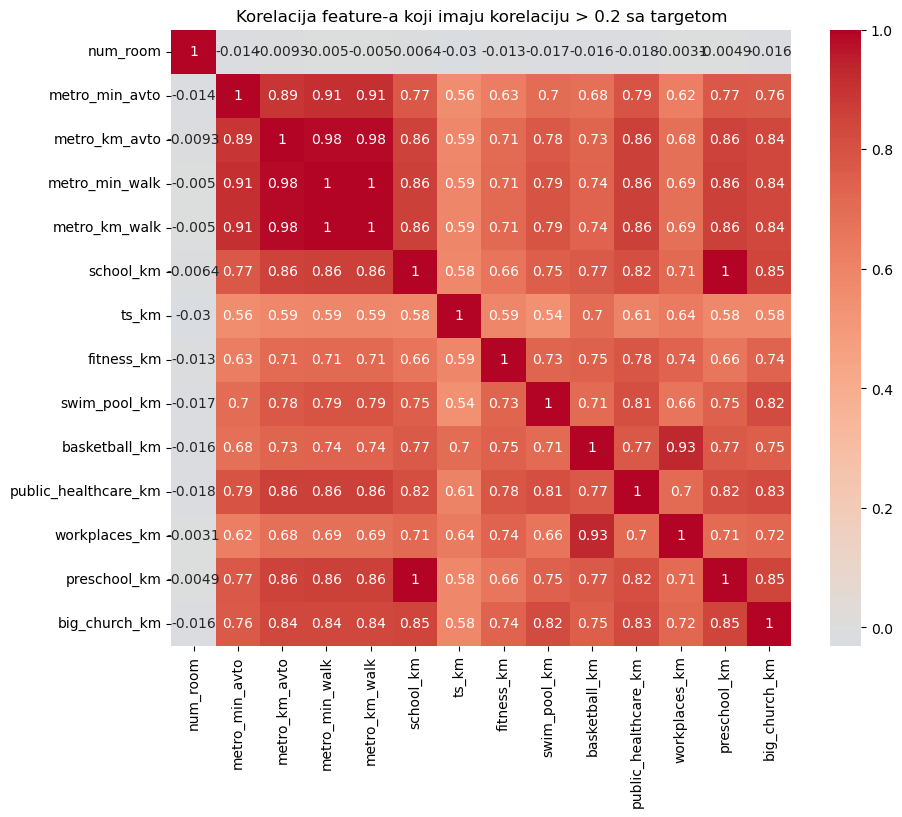

In [65]:
corr_treshold = 0.2

selected_features_num = columns_selector(train_num_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_num_with_target[selected_features_num].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [66]:
def drop_hight_corr_pairs(train_num_with_target, selected_features, pairs_treshold=0.85):

    corr_matrix = train_num_with_target[selected_features].corr()
    
    df_cleared = train_num_with_target[selected_features]
    
    target_corr = df_cleared.corrwith(y_train).abs()
    
    high_corr_pairs = [
        (col1, col2)
        for col1 in corr_matrix.columns
        for col2 in corr_matrix.columns
        if col1 < col2 and corr_matrix.loc[col1, col2] > pairs_treshold
    ]
    
    print(high_corr_pairs)
    print(f"len: {len(high_corr_pairs)}")
    print()
    print("col1 to col2 ratio")
    print()
    cols_to_drop = []
    
    for c1, c2 in high_corr_pairs:
        if target_corr.get(c1, 0) < target_corr.get(c2, 0):
            print(f"{c1} < {c2}  :  {target_corr.get(c1, 0)} < {target_corr.get(c2, 0)}")
            cols_to_drop.append(c2)
        else:
            print(f"{c2} < {c1}  :  {target_corr.get(c2, 0)} < {target_corr.get(c1, 0)}")       
            cols_to_drop.append(c1)
    
    df_cleared = df_cleared.drop(columns=cols_to_drop)
    print()
    print("columns to keep :")
    print(df_cleared.columns)
    print(f"len: {len(df_cleared.columns)}")

    return df_cleared

In [67]:
df_cleared = drop_hight_corr_pairs(train_num_with_target, selected_features_num, pairs_treshold=0.9)

[('metro_min_avto', 'metro_min_walk'), ('metro_km_avto', 'metro_min_walk'), ('metro_km_avto', 'metro_km_walk'), ('metro_km_walk', 'metro_min_avto'), ('metro_km_walk', 'metro_min_walk'), ('basketball_km', 'workplaces_km'), ('preschool_km', 'school_km')]
len: 7

col1 to col2 ratio

metro_min_avto < metro_min_walk  :  0.24032188708141972 < 0.2484672275807448
metro_km_avto < metro_min_walk  :  0.24579708203828135 < 0.2484672275807448
metro_km_avto < metro_km_walk  :  0.24579708203828135 < 0.24846722757099518
metro_min_avto < metro_km_walk  :  0.24032188708141972 < 0.24846722757099518
metro_km_walk < metro_min_walk  :  0.24846722757099518 < 0.2484672275807448
workplaces_km < basketball_km  :  0.20292984280817145 < 0.2029671072738419
preschool_km < school_km  :  0.20868493306528826 < 0.20871240534393168

columns to keep :
Index(['num_room', 'metro_min_avto', 'metro_km_avto', 'ts_km', 'fitness_km',
       'swim_pool_km', 'public_healthcare_km', 'workplaces_km', 'preschool_km',
       'big_chu

### 1. Dimenzije i sobe

full_sq → ukupna kvadratura stana (m²).

life_sq → stambena površina stana (m²), dakle samo sobe, bez hodnika, balkona i pomoćnih prostorija.

num_room → broj soba u stanu.

In [69]:
flags = []

In [70]:
def bar_plot(df, col, y_label="price_doc"):
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    plt.title(f"Distribucija {col}")
    plt.xlabel(col)
    plt.ylabel(y_label)
    plt.show()

def scatter_plot(df, col, target = "price_doc"):
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df[target], alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

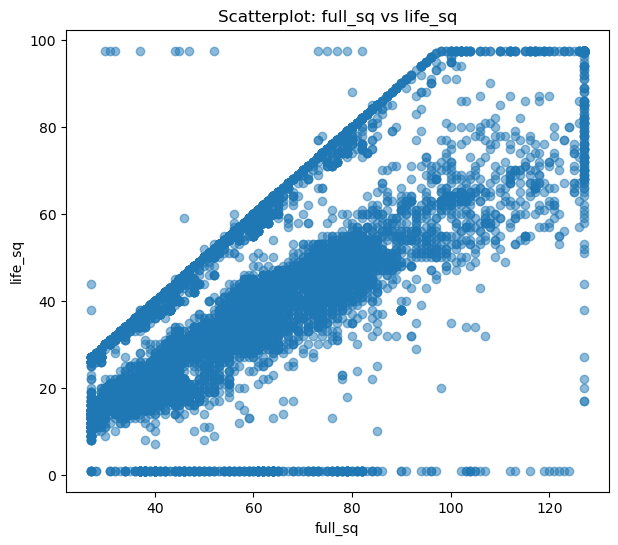

In [71]:
plt.figure(figsize=(7, 6))
plt.scatter(df["full_sq"], df["life_sq"], alpha=0.5)
plt.xlabel("full_sq")
plt.ylabel("life_sq")
plt.title("Scatterplot: full_sq vs life_sq")
plt.show()


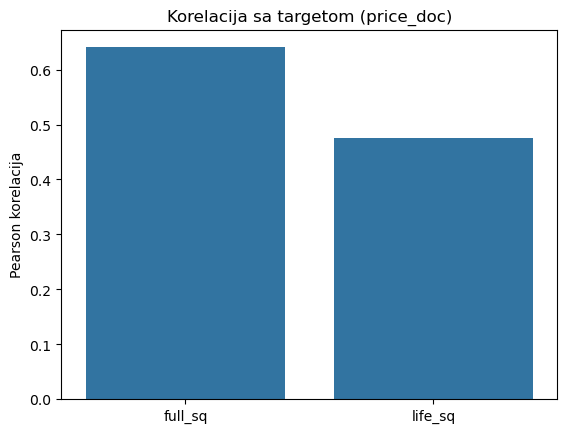

Korelacija full_sq sa targetom: 0.6410045855885002
Korelacija life_sq sa targetom: 0.47511282135448835


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Izračunaj korelaciju sa targetom
corr_full = df["full_sq"].corr(df["price_doc"])
corr_life = df["life_sq"].corr(df["price_doc"])

# Ubaci u dict pa u DataFrame za lakši plot
corr_dict = {
    "full_sq": corr_full,
    "life_sq": corr_life
}

sns.barplot(x=list(corr_dict.keys()), y=list(corr_dict.values()))
plt.title("Korelacija sa targetom (price_doc)")
plt.ylabel("Pearson korelacija")
plt.show()

print("Korelacija full_sq sa targetom:", corr_full)
print("Korelacija life_sq sa targetom:", corr_life)

* Solidna korelacija full_sq i life_sq sa targetom

* Loša međusobna korelacija

* Treba zadržati oba

In [74]:
bad_full = df[df["full_sq"] <= 0]
bad_life = df[df["life_sq"] <= 0]
bad_ratio = df[df["life_sq"] > df["full_sq"]]
bad_room_zero = df[df["num_room"] == 0]
bad_room_high = df[df["num_room"] > 10]
df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)
bad_sqm_low = df[df["sqm_per_room"] < 8]
bad_sqm_high = df[df["sqm_per_room"] > 80]


print("Provera dal postoje stanovi sa kvadraturom < 0")
print("Kvadratura <= 0:", bad_full.shape[0])
print("life_sq <= 0:", bad_life.shape[0])
print("life_sq > full_sq:", bad_ratio.shape[0])
print("num_room = 0:", bad_room_zero.shape[0])
print("num_room > 10:", bad_room_high.shape[0])
print("sqm_per_room < 8:", bad_sqm_low.shape[0])
print("sqm_per_room > 80:", bad_sqm_high.shape[0])

Provera dal postoje stanovi sa kvadraturom < 0
Kvadratura <= 0: 0
life_sq <= 0: 0
life_sq > full_sq: 30
num_room = 0: 0
num_room > 10: 0
sqm_per_room < 8: 0
sqm_per_room > 80: 63


In [75]:
# --- life_sq ---
df["life_sq_missing_or_zero"] = (df["life_sq"] <= 0).astype(int)
df["life_sq_bigger_full"] = (df["life_sq"] > df["full_sq"]).astype(int)


df.loc[df["life_sq"] <= 0, "life_sq"] = np.nan
df.loc[df["life_sq"] > df["full_sq"], "life_sq"] = np.nan

# --- num_room ---
df["num_room_zero"] = (df["num_room"] == 0).astype(int)
df["num_room_outlier"] = (df["num_room"] > 10).astype(int)

df.loc[df["num_room"] == 0, "num_room"] = np.nan
df.loc[df["num_room"] > 10, "num_room"] = np.nan

df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)

df["sqm_too_small"] = (df["sqm_per_room"] < 8).astype(int)
df["sqm_too_big"] = (df["sqm_per_room"] > 80).astype(int)

df.loc[df["sqm_per_room"] < 8, "num_room"] = np.nan
df.loc[df["sqm_per_room"] > 80, "num_room"] = np.nan


flags.extend(["life_sq_bigger_full","life_sq_bigger_full","num_room_zero","num_room_outlier","sqm_too_small","sqm_too_big"])
new_cols.extend(["sqm_per_room"])

Poredjenje full_sq sa num_room

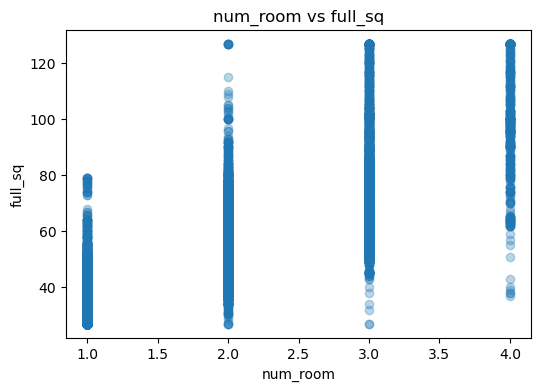

In [77]:
scatter_plot(df, col = "num_room",target="full_sq")

### 2. Saobraćaj i udaljenosti do centra

* metro_min_avto – vreme u minutima do najbliže metro stanice kolima

* kremlin_km – udaljenost u kilometrima do Kremlja

In [79]:
cols = ["metro_min_avto", "kremlin_km"]

print(df[cols].describe())

       metro_min_avto    kremlin_km
count    28878.000000  28878.000000
mean         3.638524     14.814573
std          3.117401      6.582548
min          0.096344      0.072897
25%          1.659083     10.182241
50%          2.667912     14.294238
75%          4.680384     20.362203
max         16.290779     29.133765


In [80]:
cols = ["metro_min_avto", "kremlin_km"]

thresholds = [0, 1, 2, 5, 10, 20, 50, 100]

for col in cols:
    print(f"\n=== {col} ===")
    for t in thresholds:
        count = (df[col] <= t).sum()
        print(f" <= {t}: {count}")



=== metro_min_avto ===
 <= 0: 0
 <= 1: 2275
 <= 2: 9614
 <= 5: 22971
 <= 10: 27778
 <= 20: 28878
 <= 50: 28878
 <= 100: 28878

=== kremlin_km ===
 <= 0: 0
 <= 1: 618
 <= 2: 699
 <= 5: 1971
 <= 10: 6985
 <= 20: 21312
 <= 50: 28878
 <= 100: 28878


In [81]:
mask = (df["metro_min_avto"] < 0.5) | (df["kremlin_km"] < 0.1)
df.loc[mask, ["metro_min_avto", "kremlin_km"]] = np.nan
df["is_near_kremlin"] = (df["kremlin_km"] < 1).astype(int)
flags.extend(["is_near_kremlin"])

In [82]:
df.loc[mask, ["metro_min_avto", "kremlin_km"]]

,metro_min_avto,kremlin_km
23,NaN,NaN
74,NaN,NaN
157,NaN,NaN
199,NaN,NaN
313,NaN,NaN
...,...,...
30320,NaN,NaN
30354,NaN,NaN
30377,NaN,NaN
30441,NaN,NaN


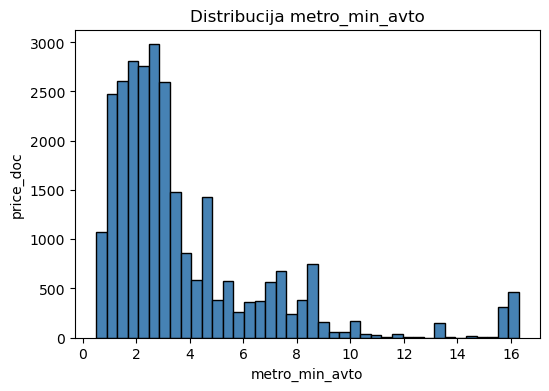

In [83]:
bar_plot(df, col = "metro_min_avto")

In [84]:
df["metro_far"] = (df["metro_min_avto"] > 30).astype(int)
df.loc[df["metro_min_avto"] > 30, "metro_min_avto"] = np.nan
flags.extend(["metro_far"])

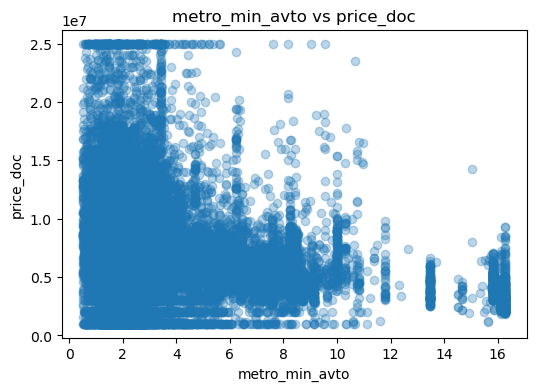

In [85]:
scatter_plot(df, col = "metro_min_avto")

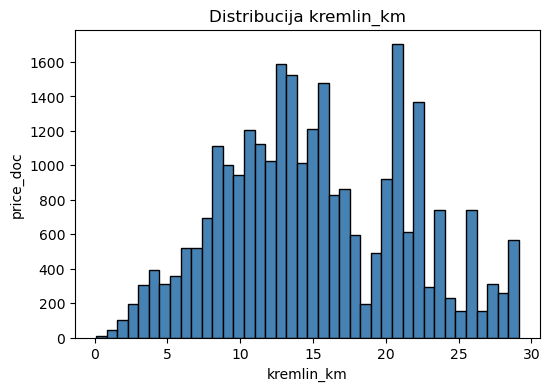

In [86]:
bar_plot(df, col = "kremlin_km")

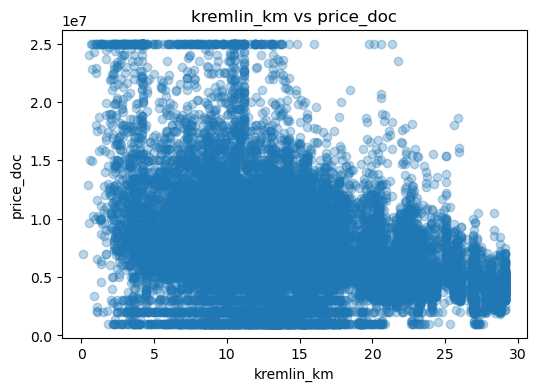

In [87]:
scatter_plot(df, col = "kremlin_km")

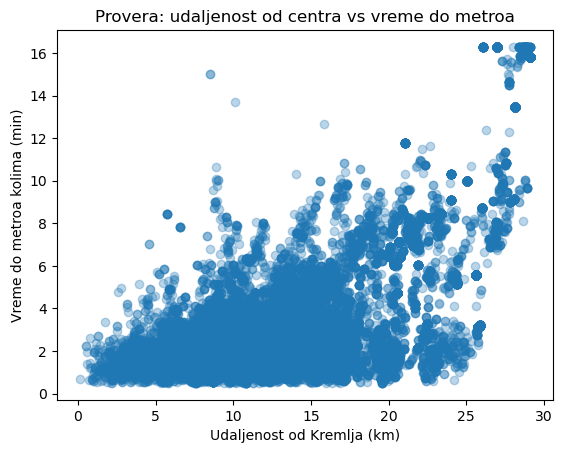

In [88]:
plt.scatter(df["kremlin_km"], df["metro_min_avto"], alpha=0.3)
plt.xlabel("Udaljenost od Kremlja (km)")
plt.ylabel("Vreme do metroa kolima (min)")
plt.title("Provera: udaljenost od centra vs vreme do metroa")
plt.show()

### 3. Okruženje i infrastruktura

* workplaces_km – udaljenost u kilometrima do poslovnih centara

* catering_km – udaljenost u kilometrima do najbližeg restorana ili ketering objekta

* big_church_km – udaljenost u kilometrima do najbliže velike crkve

In [90]:
cols = ["workplaces_km", "catering_km", "big_church_km"]

# pragovi za "previše daleko"
thresholds = {
    "workplaces_km": 50,   # poslovni centri su uglavnom u centru
    "catering_km": 20,     # restorani teško da su preko 20 km daleko
    "big_church_km": 30    # velike crkve obično u gradu
}

for col in cols:
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"> {thresholds[col]} km: {(df[col] > thresholds[col]).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")
    print()

# dodatne neusaglašenosti sa kremlin_km
print("\n=== Neusaglašenosti u odnosu na kremlin_km ===")
print("workplaces dalje od 2x kremlin:", (df["workplaces_km"] > 2 * df["kremlin_km"]).sum())
print("catering dalje od 10 km i kremlin < 5 km:", ((df["catering_km"] > 10) & (df["kremlin_km"] < 5)).sum())
print("big_church dalje od 20 km i kremlin < 5 km:", ((df["big_church_km"] > 20) & (df["kremlin_km"] < 5)).sum())



=== workplaces_km ===
Ukupno vrednosti: 28878
=0: 0
> 50 km: 0
Min: 0.16968098769999998, Max: 13.61134448


=== catering_km ===
Ukupno vrednosti: 28878
=0: 0
> 20 km: 0
Min: 0.01300334868999999, Max: 3.12114107


=== big_church_km ===
Ukupno vrednosti: 28878
=0: 0
> 30 km: 0
Min: 0.14688805071, Max: 9.55984641


=== Neusaglašenosti u odnosu na kremlin_km ===
workplaces dalje od 2x kremlin: 5
catering dalje od 10 km i kremlin < 5 km: 0
big_church dalje od 20 km i kremlin < 5 km: 0


In [91]:
df["workplaces_zero"] = (df["workplaces_km"] == 0).astype(int)
df["workplaces_far"] = (df["workplaces_km"] > 50).astype(int)
df["big_church_far"] = (df["big_church_km"] > 30).astype(int)

df.loc[df["workplaces_km"] == 0, "workplaces_km"] = np.nan
df.loc[df["workplaces_km"] > 50, "workplaces_km"] = np.nan
df.loc[df["big_church_km"] > 30, "big_church_km"] = np.nan

flags.extend(["workplaces_zero","workplaces_far","big_church_far"])

### 4. Posebne lokacije

* nuclear_reactor_km – udaljenost do nuklearnog reaktora

* detention_facility_km – udaljenost do zatvora / pritvorske jedinice


In [93]:
cols = {
    "nuclear_reactor_km": 100,       # prag za ekstremno daleko
    "detention_facility_km": 60      # prag za ekstremno daleko
}

for col, thr in cols.items():
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"<0.1 km: {(df[col] < 0.1).sum()}")   # praktično "u objektu"
    print(f"> {thr} km: {(df[col] > thr).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")



=== nuclear_reactor_km ===
Ukupno vrednosti: 28878
=0: 0
<0.1 km: 0
> 100 km: 0
Min: 1.0759076537799999, Max: 23.37647341

=== detention_facility_km ===
Ukupno vrednosti: 28878
=0: 0
<0.1 km: 0
> 60 km: 0
Min: 0.90158831531, Max: 37.32034715


In [94]:
df["detention_far"] = (df["detention_facility_km"] > 60).astype(int)
df.loc[df["detention_facility_km"] > 60, "detention_facility_km"] = np.nan
flags.extend(["detention_far"])

In [95]:
print(df.shape)

(28878, 300)


In [96]:
df_num = df.select_dtypes("number")

Feature-i sa korelacijom > 0.3 sa targetom:
['full_sq', 'life_sq', 'num_room', 'ttk_km', 'sadovoe_km', 'bulvar_ring_km', 'kremlin_km', 'zd_vokzaly_avto_km', 'price_doc_log', 'price_per_m2', 'log_price_per_m2']


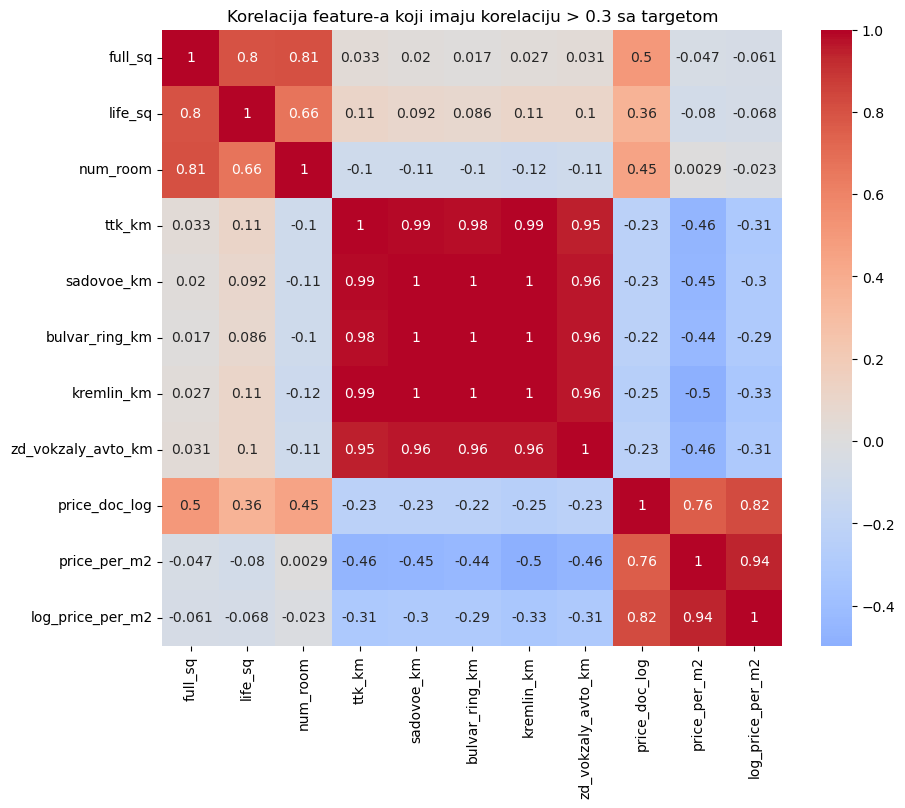

In [97]:
corr_treshold = 0.3
selected_features = columns_selector(df_num, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(df_num[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [98]:
print(flags)

['life_sq_bigger_full', 'life_sq_bigger_full', 'num_room_zero', 'num_room_outlier', 'sqm_too_small', 'sqm_too_big', 'is_near_kremlin', 'metro_far', 'workplaces_zero', 'workplaces_far', 'big_church_far', 'detention_far']


In [99]:
print(new_cols)

['year', 'month', 'floor_ratio', 'build_age', 'sqm_per_room']


In [100]:
df_cleared = drop_hight_corr_pairs(df_num, selected_features, pairs_treshold=0.9)

[('ttk_km', 'zd_vokzaly_avto_km'), ('sadovoe_km', 'ttk_km'), ('sadovoe_km', 'zd_vokzaly_avto_km'), ('bulvar_ring_km', 'ttk_km'), ('bulvar_ring_km', 'sadovoe_km'), ('bulvar_ring_km', 'kremlin_km'), ('bulvar_ring_km', 'zd_vokzaly_avto_km'), ('kremlin_km', 'ttk_km'), ('kremlin_km', 'sadovoe_km'), ('kremlin_km', 'zd_vokzaly_avto_km'), ('log_price_per_m2', 'price_per_m2')]
len: 11

col1 to col2 ratio

ttk_km < zd_vokzaly_avto_km  :  0.2861603801384823 < 0.28803811817160574
ttk_km < sadovoe_km  :  0.2861603801384823 < 0.29363327174310694
zd_vokzaly_avto_km < sadovoe_km  :  0.28803811817160574 < 0.29363327174310694
bulvar_ring_km < ttk_km  :  0.2856380798087116 < 0.2861603801384823
bulvar_ring_km < sadovoe_km  :  0.2856380798087116 < 0.29363327174310694
bulvar_ring_km < kremlin_km  :  0.2856380798087116 < 0.3220728774761618
bulvar_ring_km < zd_vokzaly_avto_km  :  0.2856380798087116 < 0.28803811817160574
ttk_km < kremlin_km  :  0.2861603801384823 < 0.3220728774761618
sadovoe_km < kremlin_km  :

In [101]:
hight_corr_cols = ['full_sq', 'life_sq', 'num_room', 'zd_vokzaly_avto_km',
       'sport_count_2000', 'office_sqm_5000', 'trc_count_5000',
       'price_doc_log', 'log_price_per_m2'],

df_cat = df.select_dtypes("object")
cat_cols = df_cat.columns
target_cols =["price_doc", "price_doc_log","price_per_m2","log_price_per_m2"]

In [102]:
cols = [c for c in df.columns if c not in target_cols]
df = df[cols + target_cols]

In [200]:
df.to_csv("data_ceaned.csv", index=False, encoding="utf-8")